In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# set a professional visualisation style
sns.set_theme(style="whitegrid")

file_path = '../data/processed/cleaned_sales_data.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])

df.head()

,date,store_id,product_id,sales_volume
0,2026-05-01,STORE_001,PROD_A,112.0
1,2026-05-01,STORE_001,PROD_B,102.0
2,2026-05-01,STORE_002,PROD_A,24.0
3,2026-05-01,STORE_002,PROD_B,116.0
4,2026-05-02,STORE_001,PROD_A,81.0


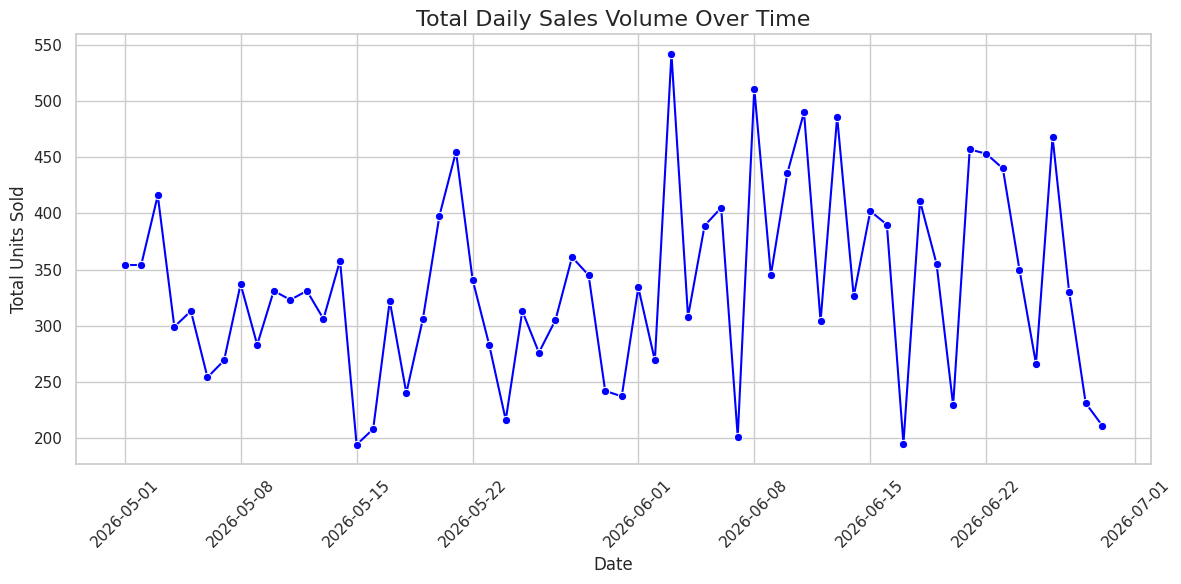

In [12]:
# 1. aggregate total daily sales across all stores and products
daily_sales = df.groupby('date')['sales_volume'].sum().reset_index()

# 2. create the visualization canvas
plt.figure(figsize=(12, 6))

# 3. plot the daily sales data
sns.lineplot(data=daily_sales, x='date', y='sales_volume', marker='o', color='blue')

# 4. add titles and labels
plt.title('Total Daily Sales Volume Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xticks(rotation=45) # tilting the dates so they dont overlap
plt.tight_layout() # prevents labels from being cut off

plt.show()


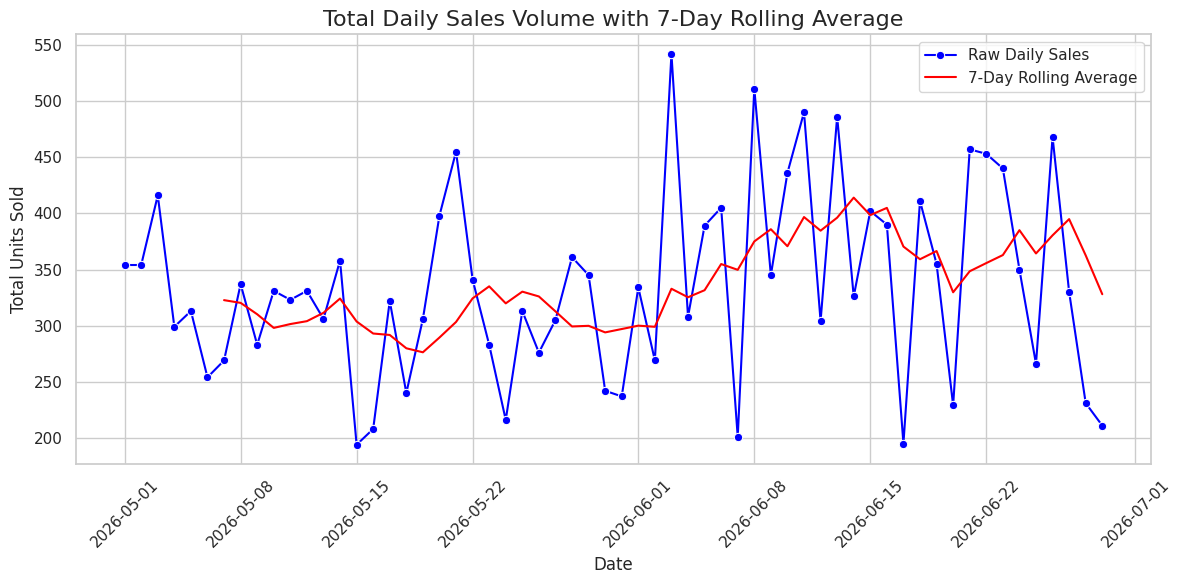

In [13]:
# 1. calculate a rolling average to smooth out the daily sales data
daily_sales['rolling_avg'] = daily_sales['sales_volume'].rolling(window=7).mean()

# 2. create the visualization canvas
plt.figure(figsize=(12, 6))

# 3. plot the daily sales data and the rolling average
sns.lineplot(data=daily_sales, x='date', y='sales_volume', marker='o', color='blue', label='Raw Daily Sales')
sns.lineplot(data=daily_sales, x='date', y='rolling_avg', color='red', label='7-Day Rolling Average')

plt.title('Total Daily Sales Volume with 7-Day Rolling Average', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xticks(rotation=45) 
plt.legend()
plt.tight_layout() 

plt.show()

In [ ]:
# 1. Extract the Day of the Week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['date'].dt.dayofweek

# 2. Map the numbers to actual names for readability
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
               4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_name'] = df['day_of_week'].map(day_mapping)

# 3. Calculate average sales per day of the week (Group by the NUMBER to keep them in calendar order!)
weekly_seasonality = df.groupby('day_of_week')['sales_volume'].mean().reset_index()
weekly_seasonality['day_name'] = weekly_seasonality['day_of_week'].map(day_mapping)

# 4. Plot the Seasonality as a Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_seasonality, x='day_name', y='sales_volume', color='teal')

plt.title('Average Sales by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Units Sold', fontsize=12)
plt.ylim(0, 150) # Set a fixed y-axis to see the differences clearly
plt.tight_layout()

plt.show()